In [18]:
from dataclasses import dataclass
from pathlib import Path
import csv

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)


def utility(w, theta, b=0.0):
    """CRRA utility with optional kinked linear extension below b."""
    w_array = np.asarray(w, dtype=float)

    if np.isclose(theta, 0.0):
        values = w_array
    elif np.isclose(theta, 1.0):
        if b > 0:
            values = np.where(
                w_array >= b,
                np.log(np.maximum(w_array, 1e-12)),
                np.log(b) * w_array,
            )
        else:
            values = np.log(np.maximum(w_array, 1e-12))
    else:
        safe_w = np.maximum(w_array, 1e-12)
        crra = (safe_w ** (1 - theta) - 1) / (1 - theta)

        if b > 0:
            u_b = (b ** (1 - theta) - 1) / (1 - theta)
            values = np.where(w_array >= b, crra, u_b * w_array)
        else:
            values = crra

    if np.isscalar(w):
        return float(np.asarray(values))
    return values


def _read_farmland_prices(path):
    prices = []
    with path.open(newline="", encoding="utf-8") as file:
        reader = csv.reader(file)
        next(reader, None)
        for row in reader:
            if not row:
                continue
            prices.append(float(row[1]))
    return np.asarray(prices, dtype=float)


def _read_sp500_values(path):
    values = []
    with path.open(newline="", encoding="utf-8") as file:
        reader = csv.reader(file)
        next(reader, None)
        for row in reader:
            if not row:
                continue
            values.append(float(row[1]))
    return np.asarray(values, dtype=float)


def _resolve_data_path(data_dir):
    """Resolve data folder from common locations used in this workspace."""
    candidate = Path(data_dir)
    if candidate.is_absolute():
        return candidate

    candidates = [
        Path.cwd() / candidate,
        Path.cwd() / "Dynamic-Programming-Project" / candidate,
        Path.cwd() / "DynPro 2026" / "Dynamic-Programming-Project" / candidate,
    ]
    for path in candidates:
        if path.exists():
            return path
    return candidates[0]


def load_historical_gross_returns(data_dir="Data"):
    data_path = _resolve_data_path(data_dir)
    farmland_prices = _read_farmland_prices(data_path / "farmland_prices.csv")
    sp500_values = _read_sp500_values(
        data_path / "sp500_inflation_adjusted_yearly_1967_2007.csv"
    )

    farmland_gross = farmland_prices[1:] / farmland_prices[:-1]
    sp500_gross = sp500_values[1:] / sp500_values[:-1]

    n = min(len(farmland_gross), len(sp500_gross))
    return farmland_gross[-n:], sp500_gross[-n:]


@dataclass
class PortfolioConfig:
    n: tuple[int, int, int, int] = (7, 7, 5, 21)
    q: int = 41
    qf: int = 21
    node: str = "nodeunif"
    m: tuple[int, int] = (5, 5)
    beta: float = 0.96
    theta: float = 0.0
    b: float = 60_000.0
    T: int = 19
    t1: int = 1
    beta0: float = 1.51181
    beta1: float = 0.742391
    alpha0: float = 0.215
    alpha1: float = 0.908361
    alpha2: float = 0.079432
    Ee: tuple[float, float] = (0.0, 0.0)
    var_cov: tuple[tuple[float, float], tuple[float, float]] = ((0.030186, 0.0), (0.0, 0.017292))
    cost: float = 231.0
    sminv: tuple[float, float, float, float] = (230.0, 1010.0, 400.0, 0.0)
    smaxv: tuple[float, float, float, float] = (540.0, 2840.0, 2000.0, 6_000_000.0)
    rp: float = 0.03
    rn: float = 0.06
    tcs: float = 0.06
    tcb: float = 0.01
    fme: float = 300.0
    fds: float = 0.07
    dau: float = 0.7
    wealth_min: float = 100.0
    wealth_max: float = 5_000.0
    wealth_size: int = 250
    action_grid_step: float = 0.1
    risk_free_gross: float | None = None
    data_dir: str = "Data"


class PortfolioChoiceModel:
    """Notebook-friendly model aligned with the Dynamic-Programming-Project style."""

    def __init__(self, config=None, farmland_gross_returns=None, sp500_gross_returns=None):
        self.config = config or PortfolioConfig()

        self.beta = float(self.config.beta)
        self.theta = float(self.config.theta)
        self.b = float(self.config.b)
        if self.config.risk_free_gross is None:
            self.risk_free_gross = 1.0 + float(self.config.rp)
        else:
            self.risk_free_gross = float(self.config.risk_free_gross)

        self.wealth_grid = np.linspace(
            self.config.wealth_min,
            self.config.wealth_max,
            self.config.wealth_size,
        )

        if farmland_gross_returns is None or sp500_gross_returns is None:
            default_farmland, default_sp500 = load_historical_gross_returns(
                self.config.data_dir
            )
            farmland_gross_returns = (
                default_farmland if farmland_gross_returns is None else farmland_gross_returns
            )
            sp500_gross_returns = (
                default_sp500 if sp500_gross_returns is None else sp500_gross_returns
            )

        self.farmland_gross_returns = np.asarray(farmland_gross_returns, dtype=float)
        self.sp500_gross_returns = np.asarray(sp500_gross_returns, dtype=float)

        if self.farmland_gross_returns.shape != self.sp500_gross_returns.shape:
            raise ValueError("Return arrays must have the same shape")

        self.actions = self._build_action_grid(self.config.action_grid_step)
        self.state_size = self.wealth_grid.size
        self.action_size = self.actions.shape[0]

    @staticmethod
    def _build_action_grid(step):
        if step <= 0 or step > 1:
            raise ValueError("action_grid_step must be in (0, 1]")

        farmland_weights = np.arange(0.0, 1.0 + 1e-12, step)
        actions = []
        for w_farmland in farmland_weights:
            sp500_weights = np.arange(0.0, 1.0 - w_farmland + 1e-12, step)
            for w_sp500 in sp500_weights:
                w_risk_free = 1.0 - w_farmland - w_sp500
                actions.append((w_risk_free, w_farmland, w_sp500))
        return np.asarray(actions, dtype=float)

    def _portfolio_gross_returns(self, action):
        return (
            action[0] * self.risk_free_gross
            + action[1] * self.farmland_gross_returns
            + action[2] * self.sp500_gross_returns
        )

    def expected_continuation_value(self, V, action):
        portfolio_returns = self._portfolio_gross_returns(action)
        next_wealth = self.wealth_grid[:, None] * portfolio_returns[None, :]
        next_wealth = np.clip(next_wealth, self.wealth_grid[0], self.wealth_grid[-1])

        interpolated = np.empty_like(next_wealth)
        for col in range(next_wealth.shape[1]):
            interpolated[:, col] = np.interp(next_wealth[:, col], self.wealth_grid, V)
        return interpolated.mean(axis=1)

    def bellman_operator(self, V):
        flow_utility = utility(self.wealth_grid, self.theta, self.b)
        value_candidates = np.empty((self.state_size, self.action_size))

        for a_idx, action in enumerate(self.actions):
            continuation = self.expected_continuation_value(V, action)
            value_candidates[:, a_idx] = flow_utility + self.beta * continuation

        policy_idx = np.argmax(value_candidates, axis=1)
        V_next = value_candidates[np.arange(self.state_size), policy_idx]
        return V_next, policy_idx

    def value_iteration(self, tol=1e-6, max_iter=2_000, return_history=False):
        V = np.zeros(self.state_size)
        history = []

        for it in range(max_iter):
            V_next, policy_idx = self.bellman_operator(V)
            error = np.max(np.abs(V_next - V))
            if return_history:
                history.append(error)
            if error < tol:
                if return_history:
                    return V_next, policy_idx, it + 1, history
                return V_next, policy_idx, it + 1
            V = V_next

        if return_history:
            return V, policy_idx, max_iter, history
        return V, policy_idx, max_iter

    def evaluate_policy(self, policy_idx, tol=1e-8, max_iter=3_000):
        V = np.zeros(self.state_size)
        flow_utility = utility(self.wealth_grid, self.theta, self.b)

        for _ in range(max_iter):
            V_next = np.empty_like(V)
            for s, a_idx in enumerate(policy_idx):
                cont = self.expected_continuation_value(V, self.actions[a_idx])
                V_next[s] = flow_utility[s] + self.beta * cont[s]
            if np.max(np.abs(V_next - V)) < tol:
                return V_next
            V = V_next

        return V

    def policy_iteration(self, tol=1e-8, max_iter=200):
        policy_idx = np.zeros(self.state_size, dtype=int)

        for it in range(max_iter):
            V_policy = self.evaluate_policy(policy_idx, tol=tol)
            _, greedy_policy = self.bellman_operator(V_policy)
            if np.array_equal(greedy_policy, policy_idx):
                return V_policy, policy_idx, it + 1
            policy_idx = greedy_policy

        V_policy = self.evaluate_policy(policy_idx, tol=tol)
        return V_policy, policy_idx, max_iter

    def chosen_actions(self, policy_idx):
        return self.actions[np.asarray(policy_idx, dtype=int)]


def plot_value_function(model, V, ax=None, title="Value Function"):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(model.wealth_grid, V, linewidth=2)
    ax.set_xlabel("Wealth")
    ax.set_ylabel("Value")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    return ax


def plot_policy_function(model, policy_idx, ax=None, title="Policy Function"):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4.5))

    chosen = model.chosen_actions(policy_idx)
    ax.plot(model.wealth_grid, chosen[:, 1], label="Farmland weight", linewidth=2)
    ax.plot(model.wealth_grid, chosen[:, 2], label="S&P500 weight", linewidth=2)
    ax.plot(model.wealth_grid, chosen[:, 0], label="Risk-free weight", linewidth=2)
    ax.set_xlabel("Wealth")
    ax.set_ylabel("Portfolio share")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    return ax

Value iteration converged in 549 iterations
Final Bellman sup-norm error: 9.630e-07
State grid size: 250, action grid size: 66


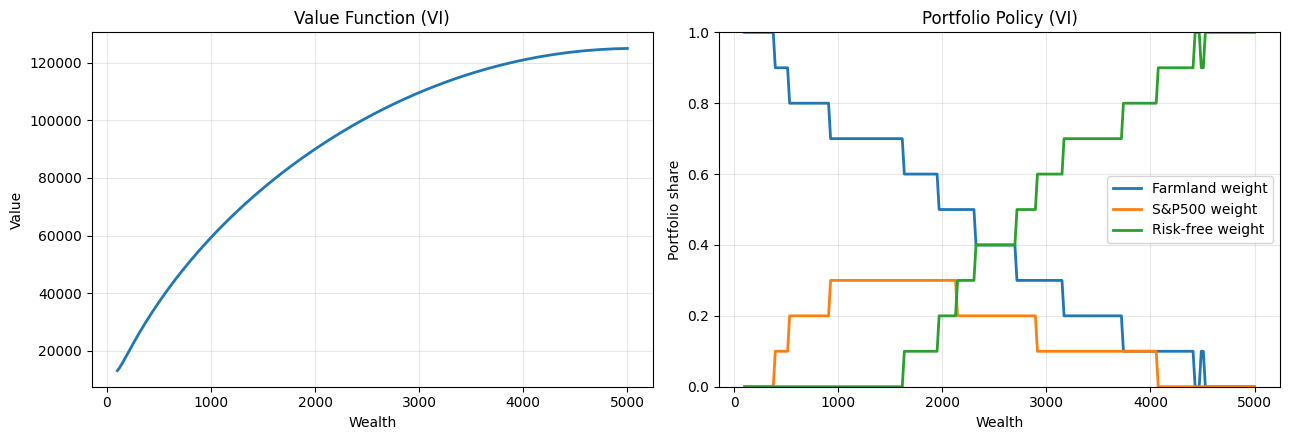

In [19]:
# Quick solve + diagnostics (aligned with Dynamic-Programming-Project workflow)
cfg = PortfolioConfig(
    beta=0.96,
    theta=0.0,
    b=60_000.0,
    wealth_min=100.0,
    wealth_max=5_000.0,
    wealth_size=250,
    action_grid_step=0.1,
    risk_free_gross=1.03,
    data_dir="Data",
)

model = PortfolioChoiceModel(config=cfg)
V_vi, pol_vi, iters_vi, hist_vi = model.value_iteration(
    tol=1e-6,
    max_iter=2_000,
    return_history=True,
)

print(f"Value iteration converged in {iters_vi} iterations")
print(f"Final Bellman sup-norm error: {hist_vi[-1]:.3e}")
print(f"State grid size: {model.state_size}, action grid size: {model.action_size}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_value_function(model, V_vi, ax=axes[0], title="Value Function (VI)")
plot_policy_function(model, pol_vi, ax=axes[1], title="Portfolio Policy (VI)")
plt.tight_layout()
plt.show()

# Optional benchmark: policy iteration is much slower for this notebook setup.
run_policy_iteration = False
if run_policy_iteration:
    V_pi, pol_pi, iters_pi = model.policy_iteration(tol=1e-6, max_iter=50)
    policy_gap = np.max(np.abs(model.actions[pol_vi] - model.actions[pol_pi]))
    print(f"Policy iteration converged in {iters_pi} iterations")
    print(f"Max difference between VI and PI chosen weights: {policy_gap:.3e}")

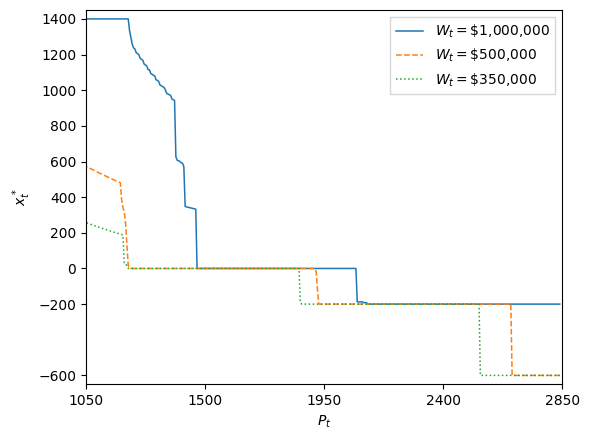

In [40]:
# Replicate x_t^* vs P_t with only notebook-defined code (no external project imports).
import math
from numpy.polynomial.hermite import hermgauss

def choose_value_maximizer(cfg):
    return "vmaxh1" if cfg.qf == 0 else "vmaxh2"


def build_model_arrays(cfg):
    n = np.array(cfg.n, dtype=int)
    sminv = np.array(cfg.sminv, dtype=float)
    smaxv = np.array(cfg.smaxv, dtype=float)
    return {
        "n": n,
        "m": np.array(cfg.m, dtype=int),
        "Ee": np.array(cfg.Ee, dtype=float),
        "VarCov": np.array(cfg.var_cov, dtype=float),
        "sminv": sminv,
        "smaxv": smaxv,
        "smin": sminv.copy(),
        "smax": smaxv.copy(),
    }


def uniform_nodes(count, low, high):
    return np.linspace(low, high, int(count), dtype=float)


def cartesian_grid(coords):
    meshes = np.meshgrid(*coords, indexing="ij")
    return np.column_stack([mesh.reshape(-1) for mesh in meshes])


def gauss_hermite_multinormal(n, mu, var):
    n = np.asarray(n, dtype=int)
    nodes, weights = [], []
    for i in range(n.size):
        x_i, w_i = hermgauss(int(n[i]))
        nodes.append(x_i * math.sqrt(2.0))
        weights.append(w_i / math.sqrt(math.pi))
    x = cartesian_grid([np.asarray(v, dtype=float) for v in nodes])
    w = np.asarray(weights[0], dtype=float)
    for wi in weights[1:]:
        w = np.kron(w, np.asarray(wi, dtype=float))
    return x @ np.linalg.cholesky(var) + mu.reshape(1, -1), w


def linear_spline_basis(n, a, b, x):
    x = np.asarray(x, dtype=float).reshape(-1)
    grid = np.linspace(a, b, int(n), dtype=float)
    h = (b - a) / (n - 1)
    basis = np.zeros((x.size, int(n)), dtype=float)
    idx = np.floor((x - a) / h).astype(int)
    idx = np.clip(idx, 0, int(n) - 2)
    left = grid[idx]
    right = grid[idx + 1]
    span = np.maximum(right - left, 1e-12)
    w_right = np.clip((x - left) / span, 0.0, 1.0)
    rows = np.arange(x.size)
    basis[rows, idx] = 1.0 - w_right
    basis[rows, idx + 1] = w_right
    return basis


def apply_inverse_basis_chain(bases, coeffs):
    coeffs = np.asarray(coeffs, dtype=float)
    z = coeffs.T.copy()
    rows_total = 1
    for basis in bases:
        basis = np.asarray(basis, dtype=float)
        ni = basis.shape[1]
        m = z.size // ni
        z = z.reshape(m, ni)
        z = basis @ z.T
        rows_total *= basis.shape[0]
    return z.reshape(rows_total, coeffs.shape[1])


def rowwise_kronecker(a, b):
    return (a[:, :, None] * b[:, None, :]).reshape(a.shape[0], a.shape[1] * b.shape[1])


def tensor_basis_interpolate(phi, coeffs):
    coeffs = np.asarray(coeffs, dtype=float)
    out = np.asarray(phi[-1], dtype=float)
    for i in range(len(phi) - 2, -1, -1):
        out = rowwise_kronecker(np.asarray(phi[i], dtype=float), out)
    return out @ coeffs


def model_utility(y, b, theta):
    yv = np.asarray(y, dtype=float)
    if theta == 0:
        return yv
    if theta == 1:
        return np.where(yv >= b, np.log(np.maximum(yv, 1e-12)), (np.log(b) / b) * yv)
    raise ValueError("utility only implemented for theta=0 or theta=1")


def model_inverse_utility(u, b, theta):
    uv = np.asarray(u, dtype=float)
    if theta == 0:
        return uv
    if theta == 1:
        return np.where(uv >= np.log(b), np.exp(uv), (uv * b) / np.log(b))
    raise ValueError("invutility only implemented for theta=0 or theta=1")


def feasible_trade_bounds(state, cfg, sminv, smaxv):
    # Bounds combine land stock limits and debt/collateral constraints.
    x_lower = sminv[2] - state[:, 2]
    x_upper_land = smaxv[2] - state[:, 2]
    sell_price = (1.0 - cfg.tcs) * state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    buy_price = (1.0 + cfg.tcb) * state[:, 1] + cfg.fme
    x_upper_debt = np.maximum(
        0.0,
        (state[:, 3] - (1.0 - cfg.dau) * sell_price * state[:, 2]) / (buy_price - cfg.dau * sell_price),
    )
    return x_lower, np.minimum(x_upper_land, x_upper_debt)


def transition_next_state(state, trade_x, shocks, cfg, sminv, smaxv):
    next_state = np.zeros_like(state, dtype=float)
    growth_r = np.exp(cfg.beta0 + cfg.beta1 * np.log(state[:, 0]) + shocks[:, 0])
    growth_p = np.exp(cfg.alpha0 + cfg.alpha1 * np.log(state[:, 1]) + cfg.alpha2 * np.log(state[:, 0]) + shocks[:, 1])
    next_state[:, 0] = np.clip(growth_r, sminv[0], smaxv[0])
    next_state[:, 1] = np.clip(growth_p, sminv[1], smaxv[1])
    next_state[:, 2] = state[:, 2] + trade_x

    buy_price = (1.0 + cfg.tcb) * state[:, 1] + cfg.fme
    sell_mask = trade_x < 0
    buy_price[sell_mask] = (1.0 - cfg.tcs) * state[sell_mask, 1] + (1.0 - cfg.fds) * cfg.fme
    sell_price_now = (1.0 - cfg.tcs) * state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    sell_price_next = (1.0 - cfg.tcs) * next_state[:, 1] + (1.0 - cfg.fds) * cfg.fme

    equity_now = state[:, 3] - sell_price_now * state[:, 2]
    base_rate = np.full(state.shape[0], cfg.rp, dtype=float)
    low_land = next_state[:, 2] < 1.0

    cash_after_trade = equity_now - buy_price * trade_x
    rate_low_land = base_rate.copy()
    rate_low_land[cash_after_trade < 0] = cfg.rn
    wealth_low_land = (1.0 + rate_low_land) * cash_after_trade

    cash_after_cost = equity_now - buy_price * trade_x - cfg.cost * next_state[:, 2]
    rate_high_land = base_rate.copy()
    rate_high_land[cash_after_cost < 0] = cfg.rn
    operating_assets = (1.0 + rate_high_land) * cash_after_cost + next_state[:, 0] * next_state[:, 2]
    wealth_high_land = operating_assets + sell_price_next * next_state[:, 2]

    next_state[:, 3] = np.where(low_land, wealth_low_land, wealth_high_land)
    return next_state


def evaluate_candidate_trade(state, coeffs, t, trade_x, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights):
    nn = state.shape[0]
    value = np.zeros(nn, dtype=float)
    n_shocks = 1 if trade_x is None else shock_nodes.shape[0]

    for k in range(n_shocks):
        if trade_x is None:
            g = state.copy()
            wk = 1.0
        else:
            ek = np.tile(shock_nodes[k], (nn, 1))
            g = transition_next_state(state, trade_x, ek, cfg, sminv, smaxv)
            wk = float(shock_weights[k])

        current_val = np.zeros(nn, dtype=float)
        low_land = g[:, 2] < 1.0
        g4 = g[:, 3]
        if np.any(low_land):
            wealth = g4[low_land]
            rate = np.full(wealth.size, cfg.rp, dtype=float)
            rate[wealth < 0] = cfg.rn
            current_val[low_land] = model_utility(((1.0 + rate) ** (cfg.T - t)) * wealth, cfg.b, cfg.theta)

        high_land = ~low_land
        if np.any(high_land):
            idx = np.where(high_land)[0]
            if coeffs is None or coeffs.size == 0:
                current_val[idx] = model_utility(g4[idx], cfg.b, cfg.theta)
            else:
                idx_pos = idx[g4[idx] > 0]
                if idx_pos.size > 0:
                    g4_cap = np.minimum(g4[idx_pos], smaxv[3])
                    residual = g4[idx_pos] - g4_cap
                    g_eval = g[idx_pos].copy()
                    g_eval[:, 3] = g4_cap
                    phi = [
                        linear_spline_basis(int(n[d]), float(smin[d]), float(smax[d]), g_eval[:, d])
                        for d in range(len(n))
                    ]
                    v_interp = tensor_basis_interpolate(phi, coeffs.reshape(-1, 1)).reshape(-1)
                    wealth_from_interp = model_inverse_utility(v_interp, cfg.b, cfg.theta)
                    over_cap = g4[idx_pos] > smaxv[3]
                    if np.any(over_cap):
                        wealth_from_interp[over_cap] = model_utility(
                            wealth_from_interp[over_cap] + ((1.0 + cfg.rp) ** (cfg.T - t)) * residual[over_cap],
                            cfg.b,
                            cfg.theta,
                        )
                    current_val[idx_pos] = wealth_from_interp
                idx_nonpos = idx[g4[idx] <= 0]
                if idx_nonpos.size > 0:
                    current_val[idx_nonpos] = model_utility(
                        ((1.0 + cfg.rn) ** (cfg.T - t)) * g4[idx_nonpos],
                        cfg.b,
                        cfg.theta,
                    )

        value += current_val * wk
    return value


def evaluate_trade_grid_with_endpoints(state, coeffs, t, x_low, x_high, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights):
    nn = state.shape[0]
    x_candidates = np.zeros((cfg.q + 2, nn), dtype=float)
    v_candidates = np.zeros((cfg.q + 2, nn), dtype=float)
    gap = (x_high - x_low) / (cfg.q - 1)

    for qi in range(cfg.q + 2):
        if qi == 0:
            x_q = np.zeros(nn, dtype=float)
        elif qi == 1:
            x_q = -state[:, 2]
        else:
            x_q = x_low + gap * (qi - 2)
        v_q = evaluate_candidate_trade(
            state, coeffs, t, x_q, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights
        )
        x_candidates[qi, :] = x_q
        v_candidates[qi, :] = v_q
    return v_candidates, x_candidates


def evaluate_trade_grid_coarse(state, coeffs, t, x_low, x_high, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights):
    nn = state.shape[0]
    x_candidates = np.zeros((cfg.q, nn), dtype=float)
    v_candidates = np.zeros((cfg.q, nn), dtype=float)
    gap = (x_high - x_low) / (cfg.q - 1)

    for qi in range(cfg.q):
        x_q = x_low + gap * qi
        v_q = evaluate_candidate_trade(
            state, coeffs, t, x_q, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights
        )
        x_candidates[qi, :] = x_q
        v_candidates[qi, :] = v_q
    return v_candidates, x_candidates


def evaluate_trade_grid_fine(state, coeffs, t, x_low, x_high, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights):
    nn = state.shape[0]
    x_candidates = np.zeros((cfg.qf + 2, nn), dtype=float)
    v_candidates = np.zeros((cfg.qf + 2, nn), dtype=float)
    gap = (x_high - x_low) / (cfg.qf - 1)

    for qi in range(cfg.qf + 2):
        if qi == 0:
            x_q = np.zeros(nn, dtype=float)
        elif qi == 1:
            x_q = -state[:, 2]
        else:
            x_q = x_low + gap * (qi - 2)
        v_q = evaluate_candidate_trade(
            state, coeffs, t, x_q, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights
        )
        x_candidates[qi, :] = x_q
        v_candidates[qi, :] = v_q
    return v_candidates, x_candidates


def maximize_value_v1(state, coeffs, t, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights):
    x_low, x_high = feasible_trade_bounds(state, cfg, sminv, smaxv)
    v_grid, x_grid = evaluate_trade_grid_with_endpoints(
        state, coeffs, t, x_low, x_high, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights
    )
    argmax_idx = np.argmax(v_grid, axis=0)
    j = np.arange(state.shape[0])
    return x_grid[argmax_idx, j], v_grid[argmax_idx, j]


def maximize_value_v2(state, coeffs, t, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights):
    x_low, x_high = feasible_trade_bounds(state, cfg, sminv, smaxv)
    v_coarse, x_coarse = evaluate_trade_grid_coarse(
        state, coeffs, t, x_low, x_high, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights
    )
    argmax_coarse = np.argmax(v_coarse, axis=0)
    j = np.arange(state.shape[0])
    x_star_coarse = x_coarse[argmax_coarse, j]

    refine_span = 1600.0 / (cfg.q - 1)
    x_refine_low = np.maximum(x_low, x_star_coarse - refine_span)
    x_refine_high = np.minimum(x_high, x_star_coarse + refine_span)

    v_fine, x_fine = evaluate_trade_grid_fine(
        state, coeffs, t, x_refine_low, x_refine_high, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights
    )
    argmax_fine = np.argmax(v_fine, axis=0)
    return x_fine[argmax_fine, j], v_fine[argmax_fine, j]


def get_value_maximizer(name):
    return maximize_value_v1 if name == "vmaxh1" else maximize_value_v2


def solve_model_coefficients(cfg):
    arrays = build_model_arrays(cfg)
    n = arrays["n"]
    m = arrays["m"]
    ee = arrays["Ee"]
    var_cov = arrays["VarCov"]
    sminv = arrays["sminv"]
    smaxv = arrays["smaxv"]
    smin = arrays["smin"]
    smax = arrays["smax"]

    shock_nodes, shock_weights = gauss_hermite_multinormal(m, ee, var_cov)
    state_nodes = [uniform_nodes(int(n[d]), float(smin[d]), float(smax[d])) for d in range(len(n))]
    inverse_basis = [
        np.linalg.inv(linear_spline_basis(int(n[d]), float(smin[d]), float(smax[d]), state_nodes[d]))
        for d in range(len(n))
    ]
    state_grid = cartesian_grid(state_nodes)

    n_points = state_grid.shape[0]
    coeffs_over_time = np.zeros((n_points, cfg.T), dtype=float)
    active_idx = np.where(state_grid[:, 3] > 1.0)[0]
    active_states = state_grid[active_idx]
    coeffs = None

    trade_x = -active_states[:, 2].copy()
    value_maximizer = get_value_maximizer(choose_value_maximizer(cfg))

    # Backward induction on t to compute interpolation coefficients c_t(s).
    for t in range(cfg.T, cfg.t1 - 1, -1):
        trade_x, value = value_maximizer(
            active_states, coeffs, t, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights
        )
        value_full = np.full(n_points, model_utility(0.0, cfg.b, cfg.theta), dtype=float)
        value_full[active_idx] = value
        coeffs = apply_inverse_basis_chain(inverse_basis, value_full.reshape(-1, 1)).reshape(-1)
        coeffs_over_time[:, t - 1] = coeffs
    return coeffs_over_time


def compute_policy_grid_local(copt, cfg, t=0, Lt=600.0, Rt=365.0, wealth_levels=None):
    arrays = build_model_arrays(cfg)
    n = arrays["n"]
    shock_nodes, shock_weights = gauss_hermite_multinormal(arrays["m"], arrays["Ee"], arrays["VarCov"])
    sminv = arrays["sminv"]
    smaxv = arrays["smaxv"]
    smin = arrays["smin"]
    smax = arrays["smax"]

    p_vals = np.arange(cfg.sminv[1], cfg.smaxv[1] + 5.0, 5.0, dtype=float)
    if wealth_levels is None:
        w_vals = np.arange(400_000.0, 1_600_000.0 + 150_000.0, 150_000.0, dtype=float)
    else:
        w_vals = np.asarray(wealth_levels, dtype=float)

    coeffs = None if t == cfg.T else copt[:, t]
    value_maximizer = get_value_maximizer(choose_value_maximizer(cfg))
    x_policy = np.zeros((p_vals.size, w_vals.size), dtype=float)

    # For each wealth slice, map price P_t to optimal trade x_t^*.
    for wi, wealth_t in enumerate(w_vals):
        state = np.zeros((p_vals.size, len(n)), dtype=float)
        state[:, 0] = Rt
        state[:, 1] = p_vals
        state[:, 2] = Lt
        state[:, 3] = wealth_t
        x_opt, _ = value_maximizer(
            state, coeffs, t, cfg, n, sminv, smaxv, smin, smax, shock_nodes, shock_weights
        )
        x_policy[:, wi] = x_opt

    return {"P": p_vals, "W": w_vals, "XP": x_policy}


# Fast structural config for notebook runtime; same model equations.
cfg_struct = PortfolioConfig()
cfg_struct.n = (5, 5, 4, 11)
cfg_struct.q = 21
cfg_struct.qf = 11
cfg_struct.m = (3, 3)
cfg_struct.T = 10
cfg_struct.t1 = 1

copt_local = solve_model_coefficients(cfg_struct)
W = np.array([1_000_000.0, 500_000.0, 350_000.0])
policy = compute_policy_grid_local(copt_local, cfg_struct, t=0, Lt=600.0, Rt=365.0, wealth_levels=W)

P = policy["P"]
XP = policy["XP"]

fig, ax = plt.subplots(figsize=(6.0, 4.5))
ax.plot(P, XP[:, 0], "-", linewidth=1.1, label=r"$W_t = \$1{,}000{,}000$")
ax.plot(P, XP[:, 1], "--", linewidth=1.1, label=r"$W_t = \$500{,}000$")
ax.plot(P, XP[:, 2], ":", linewidth=1.1, label=r"$W_t = \$350{,}000$")

ax.set_xlim(1050, 2850)
ax.set_ylim(-650, 1450)
ax.set_xlabel(r"$P_t$")
ax.set_ylabel(r"$x_t^*$")
ax.set_xticks([1050, 1500, 1950, 2400, 2850])
ax.set_yticks([-600, -200, 0, 200, 400, 600, 800, 1000, 1200, 1400])
ax.legend(loc="upper right", frameon=True, fancybox=False)
ax.grid(False)
plt.tight_layout()
plt.show()

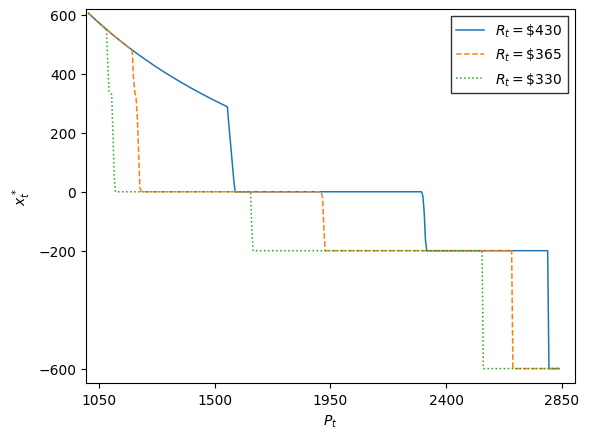

In [42]:
# Replicate x_t^* vs P_t for different R_t values (notebook-only functions).
W_fixed = np.array([500_000.0])
R_values = [430.0, 365.0, 330.0]
styles = ["-", "--", ":"]
labels = [r"$R_t = \$430$", r"$R_t = \$365$", r"$R_t = \$330$"]

curves = []
P_plot = None
for Rt in R_values:
    policy_rt = compute_policy_grid_local(
        copt_local,
        cfg_struct,
        t=0,
        Lt=600.0,
        Rt=Rt,
        wealth_levels=W_fixed,
    )
    if P_plot is None:
        P_plot = policy_rt["P"]
    curves.append(policy_rt["XP"][:, 0])

fig, ax = plt.subplots(figsize=(6.0, 4.5))
for y, style, label in zip(curves, styles, labels):
    ax.plot(P_plot, y, style, linewidth=1.1, label=label)

ax.set_xlim(1000, 2900)
ax.set_ylim(-650, 620)
ax.set_xlabel(r"$P_t$")
ax.set_ylabel(r"$x_t^*$")
ax.set_xticks([1050, 1500, 1950, 2400, 2850])
ax.set_yticks([-600, -200, 0, 200, 400, 600])
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="black", fancybox=False)
ax.grid(False)
plt.tight_layout()
plt.show()